# CO₂ growth-rate regression using anomalies

This notebook repeats the grid-point regression, but fits **anomalies** instead of raw variables.

A plain anomaly usually means subtracting a reference mean:


$$X'(t,r)=X(t,r)-\langle X(t,r)\rangle_t .$$

A standardized anomaly, or z-score anomaly, also divides by the temporal standard deviation:


$$Z_X(t,r)=\frac{X(t,r)-\langle X(t,r)\rangle_t}{\sigma_t[X(t,r)]}.$$

So anomalies are **not automatically standardized variables**. Standardized anomalies are anomalies measured in units of local temporal standard deviations.

By default this notebook uses standardized anomalies because they usually make the regression less dominated by units and scale:

$$Z_{\Delta CO_2}(t,r)
=
\beta_0(r)+\beta_E(r)Z_E(t,r)+\beta_B(r)Z_B(t,r)+\varepsilon(t,r).$$

It also removes the global annual mean from `growth_rate` before computing local anomalies, so the regression focuses on regional deviations from the global CO₂ growth signal.

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

print("Cartopy available:", HAS_CARTOPY)

Cartopy available: False


## 1. Configuration

In [8]:
INPUT_FILE = Path("unified_annual_carbon_dataset_2015_2024.nc")

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

OUTPUT_NC = OUTPUT_DIR / "gridpoint_regression_standardized_anomalies_fill0.nc"
OUTPUT_CSV = OUTPUT_DIR / "gridpoint_regression_standardized_anomalies_flat.csv"

TARGET_VAR = "growth_rate"
EMISSION_VAR = "emission"
BIO_VAR = "gosif"

# Your dataset has 10 annual observations.
MIN_OBS = 10

# Missing drivers are interpreted as zero before computing anomalies.
FILL_MISSING_DRIVERS_WITH_ZERO = True

# Recommended: remove global annual CO2 growth signal from the target first.
REMOVE_GLOBAL_ANNUAL_MEAN_FROM_TARGET = True

# True: fit z-score anomalies, (X-mean)/std.
# False: fit centered anomalies, X-mean.
STANDARDIZE_ANOMALIES = True

STD_TOL = 1e-12

## 2. Load data

In [3]:
ds = xr.open_dataset(INPUT_FILE)
ds

<xarray.Dataset> Size: 29MB
Dimensions:         (time: 10, lat: 180, lon: 360, latitude: 180, longitude: 360)
Coordinates:
  * time            (time) int64 80B 2015 2016 2017 2018 ... 2021 2022 2023 2024
  * lat             (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * latitude        (latitude) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude       (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    growth_rate     (time, lat, lon) float64 5MB ...
    emission        (time, lat, lon) float32 3MB ...
    gosif           (time, lat, lon) float32 3MB ...
    delta_emission  (time, lat, lon) float32 3MB ...
    delta_gosif     (time, lat, lon) float32 3MB ...
    cams_xco2       (time, latitude, longitude) float32 3MB ...
    growth_err      (time, lat, lon) float64 5MB ...
    mean_co2        (time, lat, lon) float64 5MB ...
Attributes:
    description:  Unified annual carbon dataset on growth-rate grid. Contains...

In [6]:
y_raw = ds[TARGET_VAR].transpose("time", "lat", "lon")
e_raw = ds[EMISSION_VAR].transpose("time", "lat", "lon")
b_raw = ds[BIO_VAR].transpose("time", "lat", "lon")

if FILL_MISSING_DRIVERS_WITH_ZERO:
    e_filled = e_raw.fillna(0)
    b_filled = b_raw.fillna(0)
else:
    e_filled = e_raw
    b_filled = b_raw

print("growth_rate shape:", y_raw.shape)
print("emission shape:", e_filled.shape)
print("gosif shape:", b_filled.shape)

growth_rate shape: (10, 180, 360)
emission shape: (10, 180, 360)
gosif shape: (10, 180, 360)


## 3. Compute anomaly variables

The target is treated slightly differently from the drivers.

For the target `growth_rate`, we optionally subtract the global annual mean first:


$$Y_{\mathrm{regional}}(t,r)=Y(t,r)-\langle Y(t,r)\rangle_{\mathrm{global}}.$$

Then we compute temporal anomalies at each grid point. This removes the local mean over 2015--2024.

For `emission` and `gosif`, we fill missing values with zero first, then compute temporal anomalies.

In [9]:
def temporal_center(da):
    return da - da.mean(dim="time", skipna=True)

def temporal_zscore(da, constant_fill_value=np.nan):
    mean = da.mean(dim="time", skipna=True)
    std = da.std(dim="time", skipna=True)
    centered = da - mean
    z = centered / std
    z = z.where(std > STD_TOL, constant_fill_value)
    return z, centered, mean, std

# Remove global annual mean from target if requested
if REMOVE_GLOBAL_ANNUAL_MEAN_FROM_TARGET:
    lat_weights = np.cos(np.deg2rad(y_raw["lat"]))
    global_annual_mean = y_raw.weighted(lat_weights).mean(dim=("lat", "lon"))
    y_base = y_raw - global_annual_mean
else:
    global_annual_mean = xr.zeros_like(y_raw.mean(dim=("lat", "lon")))
    y_base = y_raw

# Compute centered anomalies and standardized anomalies
if STANDARDIZE_ANOMALIES:
    # If target has zero temporal std, mark it as NaN; no useful regression.
    y_reg, y_centered, y_mean, y_std = temporal_zscore(y_base, constant_fill_value=np.nan)
    # If predictors have zero temporal std, set them to zero; they will be ignored in regression.
    e_reg, e_centered, e_mean, e_std = temporal_zscore(e_filled, constant_fill_value=0)
    b_reg, b_centered, b_mean, b_std = temporal_zscore(b_filled, constant_fill_value=0)
    regression_space = "standardized anomalies"
else:
    y_centered = temporal_center(y_base)
    e_centered = temporal_center(e_filled)
    b_centered = temporal_center(b_filled)
    y_reg = y_centered
    e_reg = e_centered
    b_reg = b_centered
    y_mean = y_base.mean(dim="time", skipna=True)
    e_mean = e_filled.mean(dim="time", skipna=True)
    b_mean = b_filled.mean(dim="time", skipna=True)
    y_std = y_base.std(dim="time", skipna=True)
    e_std = e_filled.std(dim="time", skipna=True)
    b_std = b_filled.std(dim="time", skipna=True)
    regression_space = "centered anomalies"

print("Regression space:", regression_space)
print("Target finite fraction:", float(np.isfinite(y_reg).mean()))
print("Emission finite fraction:", float(np.isfinite(e_reg).mean()))
print("GOSIF finite fraction:", float(np.isfinite(b_reg).mean()))

Regression space: standardized anomalies
Target finite fraction: 1.0
Emission finite fraction: 1.0
GOSIF finite fraction: 1.0


## 4. Fit one anomaly regression per grid point

In [11]:
def fit_one_grid_point(y, emission, bio, min_obs=10, std_tol=1e-12):
    y = np.asarray(y, dtype=float)
    emission = np.asarray(emission, dtype=float)
    bio = np.asarray(bio, dtype=float)

    valid = np.isfinite(y) & np.isfinite(emission) & np.isfinite(bio)
    n_obs = int(np.sum(valid))
    y_pred = np.full_like(y, np.nan, dtype=float)

    if n_obs < min_obs:
        return np.nan, np.nan, np.nan, np.nan, np.nan, n_obs, 0, 0, y_pred

    yv = y[valid]
    ev = emission[valid]
    bv = bio[valid]

    X_cols = [np.ones(n_obs)]
    names = ["intercept"]

    use_emission = np.nanstd(ev) > std_tol
    if use_emission:
        X_cols.append(ev)
        names.append("emission")

    use_bio = np.nanstd(bv) > std_tol
    if use_bio:
        X_cols.append(bv)
        names.append("bio")

    X = np.column_stack(X_cols)
    rank = np.linalg.matrix_rank(X)
    n_predictors_used = len(names) - 1

    beta_active, _, _, _ = np.linalg.lstsq(X, yv, rcond=None)

    beta0 = beta_active[0]
    beta_E = 0.0
    beta_B = 0.0

    idx = 1
    if use_emission:
        beta_E = beta_active[idx]
        idx += 1
    if use_bio:
        beta_B = beta_active[idx]

    pred_valid = np.isfinite(emission) & np.isfinite(bio)
    y_pred[pred_valid] = beta0 + beta_E * emission[pred_valid] + beta_B * bio[pred_valid]

    residuals = yv - (beta0 + beta_E * ev + beta_B * bv)
    rss = np.sum(residuals ** 2)
    tss = np.sum((yv - np.mean(yv)) ** 2)
    r2 = 1.0 - rss / tss if tss > 0 else np.nan
    rmse = np.sqrt(np.mean(residuals ** 2))

    return beta0, beta_E, beta_B, r2, rmse, n_obs, n_predictors_used, rank, y_pred

In [12]:
y = y_reg.values
emission = e_reg.values
bio = b_reg.values

n_time, n_lat, n_lon = y.shape
n_grid = n_lat * n_lon

print(f"Years: {n_time}")
print(f"Grid cells: {n_grid}")

y_flat = y.reshape(n_time, n_grid)
emission_flat = emission.reshape(n_time, n_grid)
bio_flat = bio.reshape(n_time, n_grid)

beta0_flat = np.full(n_grid, np.nan)
beta_E_flat = np.full(n_grid, np.nan)
beta_B_flat = np.full(n_grid, np.nan)
r2_flat = np.full(n_grid, np.nan)
rmse_flat = np.full(n_grid, np.nan)
n_obs_flat = np.zeros(n_grid, dtype=np.int16)
n_predictors_used_flat = np.zeros(n_grid, dtype=np.int16)
rank_flat = np.zeros(n_grid, dtype=np.int16)
pred_flat = np.full((n_time, n_grid), np.nan)

for k in range(n_grid):
    beta0, beta_E, beta_B, r2, rmse, n_obs, n_predictors_used, rank, y_pred = fit_one_grid_point(
        y_flat[:, k],
        emission_flat[:, k],
        bio_flat[:, k],
        min_obs=MIN_OBS,
        std_tol=STD_TOL,
    )

    beta0_flat[k] = beta0
    beta_E_flat[k] = beta_E
    beta_B_flat[k] = beta_B
    r2_flat[k] = r2
    rmse_flat[k] = rmse
    n_obs_flat[k] = n_obs
    n_predictors_used_flat[k] = n_predictors_used
    rank_flat[k] = rank
    pred_flat[:, k] = y_pred

    if (k + 1) % 10000 == 0:
        print(f"Processed {k + 1} / {n_grid}")

print("Done.")
print("Valid regressions:", int(np.isfinite(beta0_flat).sum()))

Years: 10
Grid cells: 64800
Processed 10000 / 64800
Processed 20000 / 64800
Processed 30000 / 64800
Processed 40000 / 64800
Processed 50000 / 64800
Processed 60000 / 64800
Done.
Valid regressions: 64800


## 5. Build and save output dataset

In [13]:
beta0 = beta0_flat.reshape(n_lat, n_lon)
beta_E = beta_E_flat.reshape(n_lat, n_lon)
beta_B = beta_B_flat.reshape(n_lat, n_lon)
r2 = r2_flat.reshape(n_lat, n_lon)
rmse = rmse_flat.reshape(n_lat, n_lon)
n_obs = n_obs_flat.reshape(n_lat, n_lon)
n_predictors_used = n_predictors_used_flat.reshape(n_lat, n_lon)
rank = rank_flat.reshape(n_lat, n_lon)

predicted_target = pred_flat.reshape(n_time, n_lat, n_lon)
residual_target = y - predicted_target

emission_nonconstant = e_std > STD_TOL
gosif_nonconstant = b_std > STD_TOL
target_nonconstant = y_std > STD_TOL

out_anom = xr.Dataset(
    data_vars={
        "beta0": (("lat", "lon"), beta0),
        "beta_E": (("lat", "lon"), beta_E),
        "beta_B": (("lat", "lon"), beta_B),
        "r2": (("lat", "lon"), r2),
        "rmse": (("lat", "lon"), rmse),
        "n_obs": (("lat", "lon"), n_obs),
        "n_predictors_used": (("lat", "lon"), n_predictors_used),
        "design_matrix_rank": (("lat", "lon"), rank),
        "predicted_target": (("time", "lat", "lon"), predicted_target),
        "residual_target": (("time", "lat", "lon"), residual_target),
        "target_for_regression": y_reg,
        "emission_for_regression": e_reg,
        "gosif_for_regression": b_reg,
        "growth_rate_background_removed": y_base,
        "growth_rate_centered_anomaly": y_centered,
        "emission_centered_anomaly": e_centered,
        "gosif_centered_anomaly": b_centered,
        "growth_rate_temporal_mean": y_mean,
        "emission_temporal_mean": e_mean,
        "gosif_temporal_mean": b_mean,
        "growth_rate_temporal_std": y_std,
        "emission_temporal_std": e_std,
        "gosif_temporal_std": b_std,
        "emission_nonconstant": emission_nonconstant,
        "gosif_nonconstant": gosif_nonconstant,
        "target_nonconstant": target_nonconstant,
    },
    coords={
        "time": y_reg["time"].values,
        "lat": y_reg["lat"].values,
        "lon": y_reg["lon"].values,
    },
    attrs={
        "title": "Grid-point regression of CO2 growth-rate anomalies from emission and GOSIF anomalies",
        "regression_space": regression_space,
        "model": "target_for_regression = beta0 + beta_E * emission_for_regression + beta_B * gosif_for_regression",
        "target_variable": TARGET_VAR,
        "emission_variable": EMISSION_VAR,
        "biospheric_variable": BIO_VAR,
        "missing_emission_handling": "NaN values filled with 0 before computing anomalies",
        "missing_gosif_handling": "NaN values filled with 0 before computing anomalies",
        "remove_global_annual_mean_from_target": str(REMOVE_GLOBAL_ANNUAL_MEAN_FROM_TARGET),
        "standardize_anomalies": str(STANDARDIZE_ANOMALIES),
        "minimum_observations": MIN_OBS,
    },
)

out_anom["beta_E"].attrs["description"] = "Coefficient for emission anomalies."
out_anom["beta_B"].attrs["description"] = "Coefficient for GOSIF anomalies."
out_anom["r2"].attrs["description"] = "R squared of local anomaly regression."

encoding = {var: {"zlib": True, "complevel": 4} for var in out_anom.data_vars}
out_anom.to_netcdf(OUTPUT_NC, encoding=encoding)

flat = out_anom[
    ["beta0", "beta_E", "beta_B", "r2", "rmse", "n_obs",
     "n_predictors_used", "design_matrix_rank",
     "emission_nonconstant", "gosif_nonconstant", "target_nonconstant"]
].to_dataframe().reset_index()
flat.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_NC)
print("Saved:", OUTPUT_CSV)
out_anom

Saved: outputs\gridpoint_regression_standardized_anomalies_fill0.nc
Saved: outputs\gridpoint_regression_standardized_anomalies_flat.csv


<xarray.Dataset> Size: 42MB
Dimensions:                         (lat: 180, lon: 360, time: 10)
Coordinates:
  * lat                             (lat) float64 1kB -89.5 -88.5 ... 88.5 89.5
  * lon                             (lon) float64 3kB -179.5 -178.5 ... 179.5
  * time                            (time) int64 80B 2015 2016 ... 2023 2024
Data variables: (12/26)
    beta0                           (lat, lon) float64 518kB -5.266e-17 ... -...
    beta_E                          (lat, lon) float64 518kB 0.0 0.0 ... -0.1478
    beta_B                          (lat, lon) float64 518kB 0.0 0.0 ... 0.0 0.0
    r2                              (lat, lon) float64 518kB 0.0 0.0 ... 0.02185
    rmse                            (lat, lon) float64 518kB 1.0 1.0 ... 0.989
    n_obs                           (lat, lon) int16 130kB 10 10 10 ... 10 10 10
    ...                              ...
    growth_rate_temporal_std        (lat, lon) float64 518kB 0.174 ... 0.25
    emission_temporal_std           (lat, lon) float32 259kB 0.0 0.0 ... 0.3592
    gosif_temporal_std              (lat, lon) float32 259kB 0.0 0.0 ... 0.0 0.0
    emission_nonconstant            (lat, lon) bool 65kB False False ... True
    gosif_nonconstant               (lat, lon) bool 65kB False False ... False
    target_nonconstant              (lat, lon) bool 65kB True True ... True True
Attributes:
    title:                                  Grid-point regression of CO2 grow...
    regression_space:                       standardized anomalies
    model:                                  target_for_regression = beta0 + b...
    target_variable:                        growth_rate
    emission_variable:                      emission
    biospheric_variable:                    gosif
    missing_emission_handling:              NaN values filled with 0 before c...
    missing_gosif_handling:                 NaN values filled with 0 before c...
    remove_global_annual_mean_from_target:  True
    standardize_anomalies:                  True
    minimum_observations:                   10

## 6. Plot maps

In [14]:
def plot_map_xarray(da, title=None, cmap="coolwarm", robust=True, save_path=None):
    if title is None:
        title = da.name

    if HAS_CARTOPY:
        fig = plt.figure(figsize=(13, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        da.plot(
            ax=ax,
            x="lon",
            y="lat",
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            robust=robust,
            cbar_kwargs={"label": da.name},
        )
        ax.coastlines(linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4)
        ax.set_global()
        ax.set_title(title)
    else:
        plt.figure(figsize=(12, 5))
        da.plot(
            x="lon",
            y="lat",
            cmap=cmap,
            robust=robust,
            cbar_kwargs={"label": da.name},
        )
        plt.title(title)
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

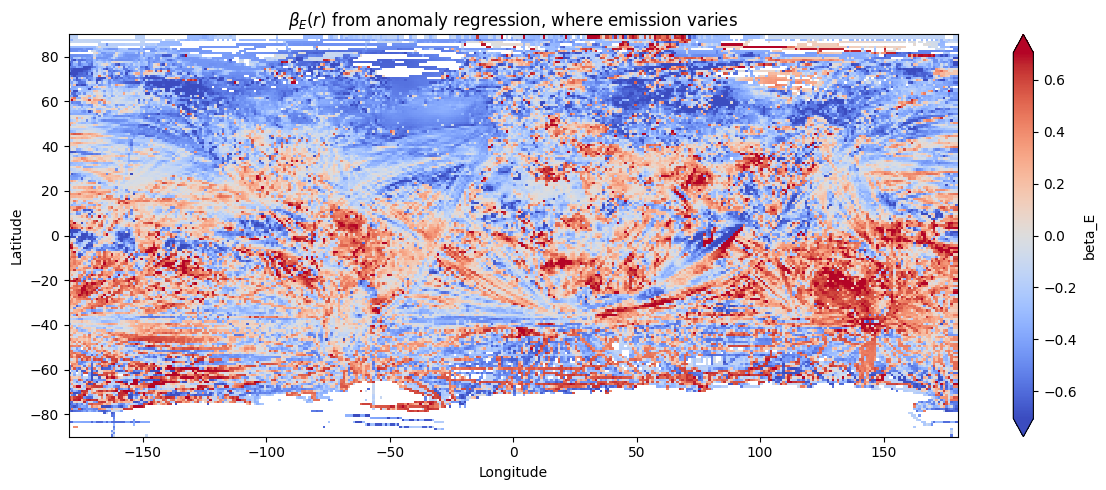

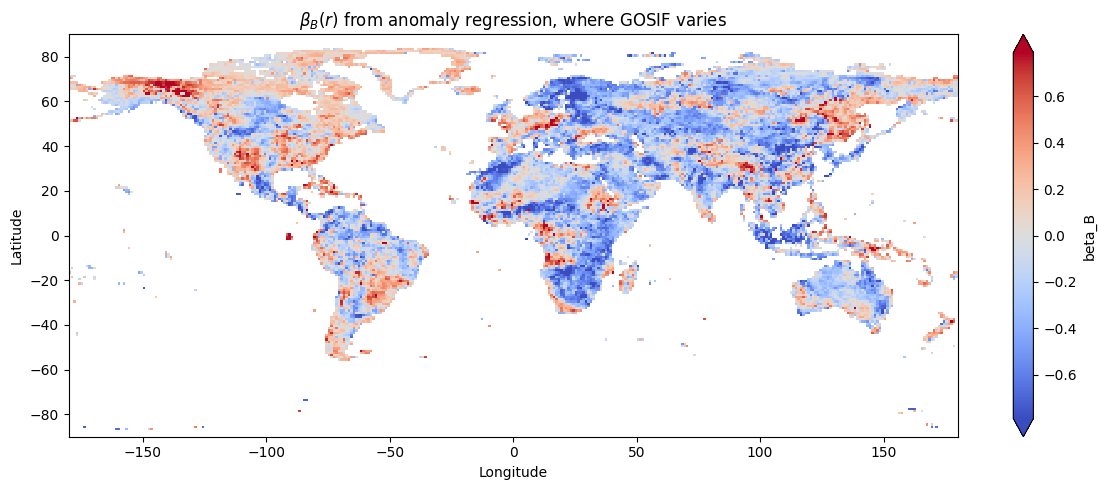

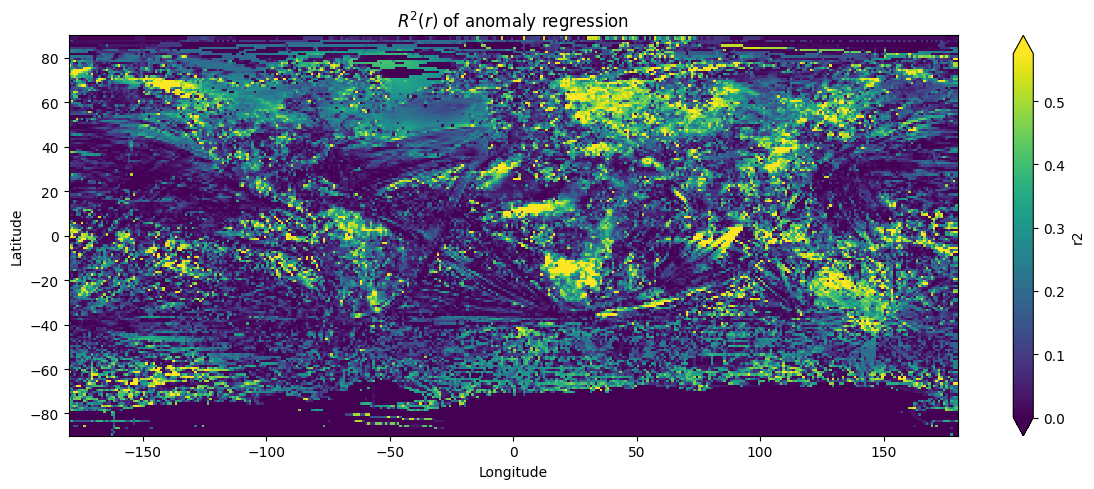

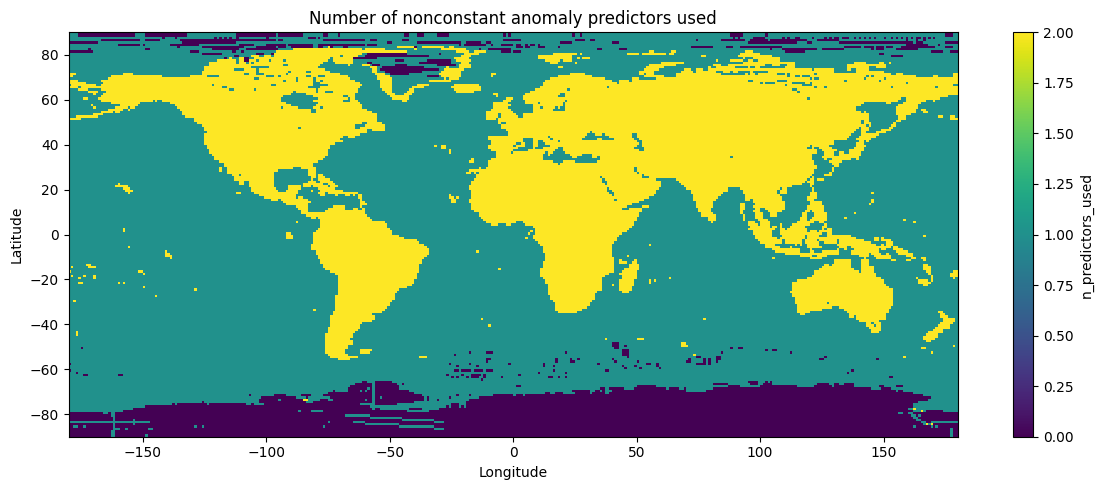

In [15]:
plot_map_xarray(
    out_anom["beta_E"].where(out_anom["emission_nonconstant"]),
    title=r"$\beta_E(r)$ from anomaly regression, where emission varies",
    cmap="coolwarm",
    robust=True,
    save_path=FIGURE_DIR / "anomaly_beta_E_map.png",
)

plot_map_xarray(
    out_anom["beta_B"].where(out_anom["gosif_nonconstant"]),
    title=r"$\beta_B(r)$ from anomaly regression, where GOSIF varies",
    cmap="coolwarm",
    robust=True,
    save_path=FIGURE_DIR / "anomaly_beta_B_map.png",
)

plot_map_xarray(
    out_anom["r2"],
    title=r"$R^2(r)$ of anomaly regression",
    cmap="viridis",
    robust=True,
    save_path=FIGURE_DIR / "anomaly_r2_map.png",
)

plot_map_xarray(
    out_anom["n_predictors_used"],
    title="Number of nonconstant anomaly predictors used",
    cmap="viridis",
    robust=False,
    save_path=FIGURE_DIR / "anomaly_n_predictors_used.png",
)

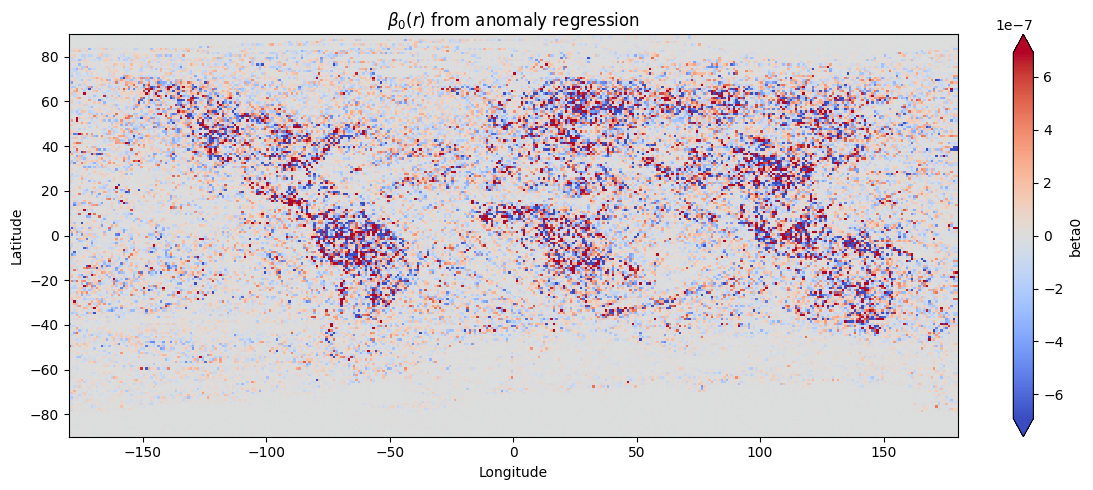

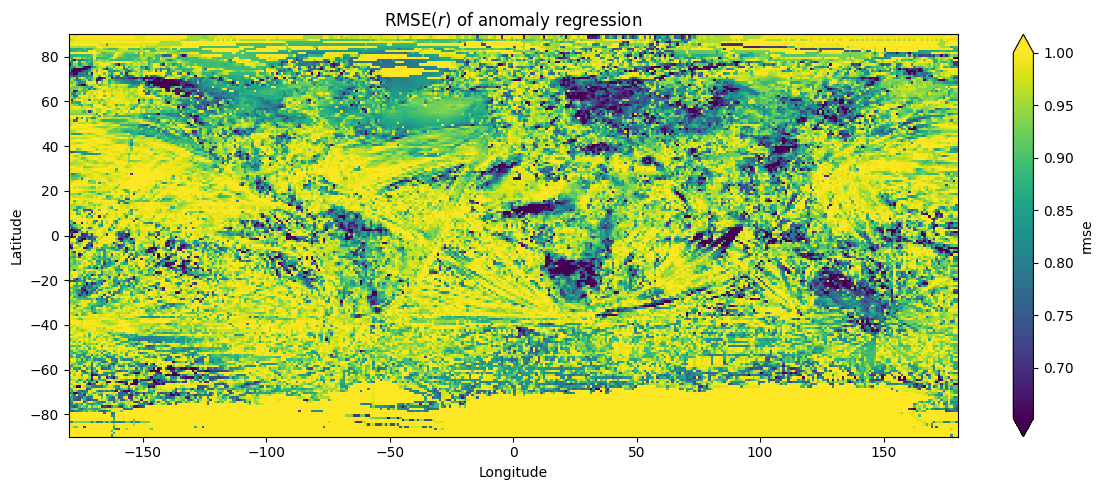

In [17]:
# ------------------------------------------------------------
# Plot beta_0 and RMSE maps from the anomaly regression
# ------------------------------------------------------------

plot_map_xarray(
    out_anom["beta0"],
    title=r"$\beta_0(r)$ from anomaly regression",
    cmap="coolwarm",
    robust=True,
    save_path=FIGURE_DIR / "anomaly_beta0_map.png",
)

plot_map_xarray(
    out_anom["rmse"],
    title=r"RMSE$(r)$ of anomaly regression",
    cmap="viridis",
    robust=True,
    save_path=FIGURE_DIR / "anomaly_rmse_map.png",
)

## 7. Plot observed, predicted, and residual anomaly for one year

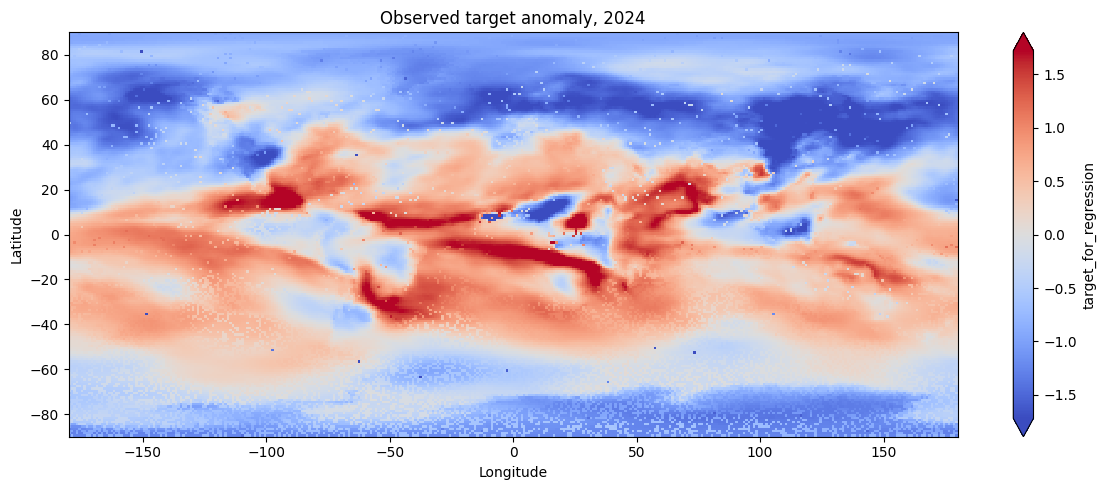

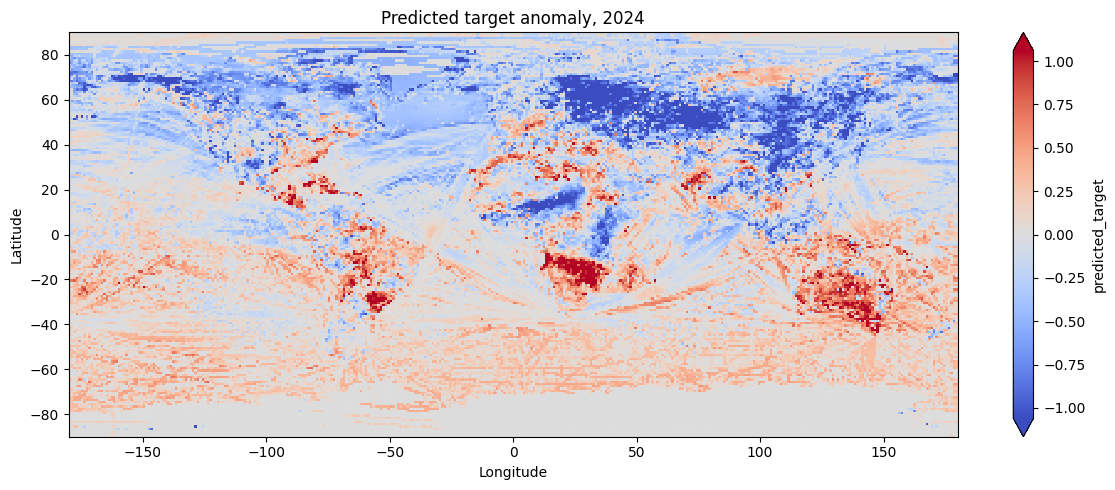

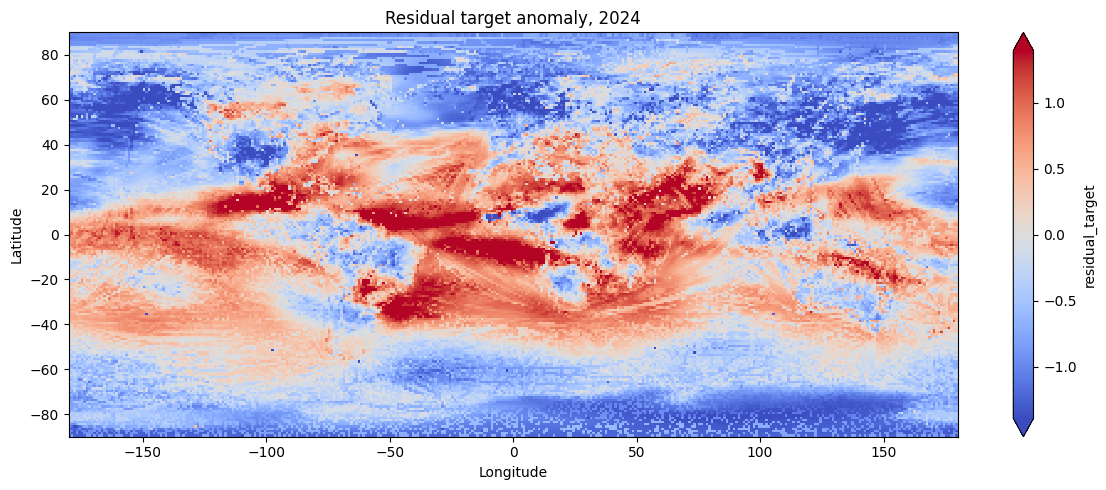

In [16]:
YEAR_TO_PLOT = 2024

obs = out_anom["target_for_regression"].sel(time=YEAR_TO_PLOT)
pred = out_anom["predicted_target"].sel(time=YEAR_TO_PLOT)
resid = out_anom["residual_target"].sel(time=YEAR_TO_PLOT)

plot_map_xarray(
    obs,
    title=f"Observed target anomaly, {YEAR_TO_PLOT}",
    cmap="coolwarm",
    robust=True,
    save_path=FIGURE_DIR / f"anomaly_observed_target_{YEAR_TO_PLOT}.png",
)

plot_map_xarray(
    pred,
    title=f"Predicted target anomaly, {YEAR_TO_PLOT}",
    cmap="coolwarm",
    robust=True,
    save_path=FIGURE_DIR / f"anomaly_predicted_target_{YEAR_TO_PLOT}.png",
)

plot_map_xarray(
    resid,
    title=f"Residual target anomaly, {YEAR_TO_PLOT}",
    cmap="coolwarm",
    robust=True,
    save_path=FIGURE_DIR / f"anomaly_residual_target_{YEAR_TO_PLOT}.png",
)

## 8. Inspect one site

In [ ]:
SITES = {
    "London": (51.5074, -0.1278),
    "Manaus": (-3.119, -60.022),
}

fig, axes = plt.subplots(len(SITES), 1, figsize=(9, 4 * len(SITES)), sharex=True)
if len(SITES) == 1:
    axes = [axes]

for ax, (name, (la, lo)) in zip(axes, SITES.items()):
    obs = out_anom["target_for_regression"].sel(lat=la, lon=lo, method="nearest")
    pred = out_anom["predicted_target"].sel(lat=la, lon=lo, method="nearest")
    resid = out_anom["residual_target"].sel(lat=la, lon=lo, method="nearest")
    c = out_anom.sel(lat=la, lon=lo, method="nearest")

    ax.plot(obs["time"], obs, marker="o", label="Observed anomaly")
    ax.plot(pred["time"], pred, marker="o", label="Predicted anomaly")
    ax.plot(resid["time"], resid, marker="o", linestyle="--", label="Residual")
    ax.axhline(0, linewidth=0.8)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_ylabel("Anomaly units")
    ax.set_title(
        f"{name}: beta_E={float(c['beta_E']):.2f}, "
        f"beta_B={float(c['beta_B']):.2f}, R2={float(c['r2']):.2f}"
    )

axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.show()

## Notes for interpretation

If `STANDARDIZE_ANOMALIES = True`, the model is fitted in z-score units.

That means:

- \(\beta_E(r)\) is the expected change in standardized CO₂ growth-rate anomaly for a one-standard-deviation increase in local emission anomaly.
- \(\beta_B(r)\) is the expected change in standardized CO₂ growth-rate anomaly for a one-standard-deviation increase in local GOSIF anomaly.
- \(\beta_E\) and \(\beta_B\) are directly comparable.
- The intercept \(\beta_0\) should be close to zero because all variables are centered.

This should usually be less noisy and more interpretable than the raw regression, but remember that each local regression still only uses 10 annual data points.